# 01 – Explore MIT-BIH Dataset
Use this notebook to inspect raw signals, annotations, and label distributions.

### Loading the raw data from it

In [7]:
from __future__ import annotations
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np


In [8]:
def _default_data_root() -> Path:
    """Search for data/mitbih robustly."""
    candidates: list[Path] = []

    # If running in scripts
    try:
        candidates.append(Path(__file__).resolve().parents[2])
    except NameError:
        # __file__ is undefined in Jupyter, so start from cwd() instead
        candidates.append(Path.cwd().resolve())

    # Add parent dirs of cwd (for notebooks)
    cwd = Path.cwd().resolve()
    candidates.append(cwd)
    candidates.extend(cwd.parents)

    # Try all candidates
    for base in candidates:
        candidate = base / "data" / "mitbih"
        if candidate.exists():
            return candidate

    # Final fallback
    return cwd / "data" / "mitbih"


### WFDB를 써야 하는 이유
- **공식 생체신호 툴킷**: PhysioNet 팀이 유지보수하며 MIT-BIH 형식을 완벽 지원한다.
- **핵심 기능**: `.hea` 메타데이터 파싱, ECG/PPG/EEG/ABP 로딩, 잡음 구간/annotation 활용, R-peak 및 필터링 유틸 제공.
- **연구 생산성**: 레코드와 annotation을 한 번에 읽어 ground truth를 확보하고 재현성 있는 전처리 파이프라인을 쉽게 구현한다.
- **시간 절약**: 직접 파서/필터를 구현하면 수 주가 걸리지만 WFDB로는 몇 시간 안에 동일한 결과 확보.

#### 다른 라이브러리와 비교
| 방법 | 장점 | 치명적 단점 |
| --- | --- | --- |
| **SciPy·NumPy 직접 파싱** | lightweight | MIT-BIH 포맷 파싱 및 annotation 처리 필요 |
| **BioSPPy** | ECG 자동 전처리 | MIT-BIH 완전 호환 아님, annotation 약함 |
| **PyWavelets** | 웨이블릿 기반 이상치 탐지 | 데이터 파싱 기능 없음 |
| **MNE (EEG 중심)** | 시각화/전처리 강함 | ECG 연구에는 과도하게 무거움 |


### Why WFDB?

MIT-BIH Arrhythmia Database uses a specialized format (.dat, .hea, .atr) that
contains encoded waveform data and associated annotations. Manually parsing
these files is time-consuming and error-prone.

WFDB is the official PhysioNet-supported toolkit that provides:

- Reliable loading of ECG signals and annotations
- Consistent sampling rate/metadata parsing
- Built-in ECG processing utilities (filtering, R-peak detection, etc.)
- Reproducible preprocessing pipelines widely used in academic research

For these reasons, WFDB is chosen as the primary data-loading backend for this project.


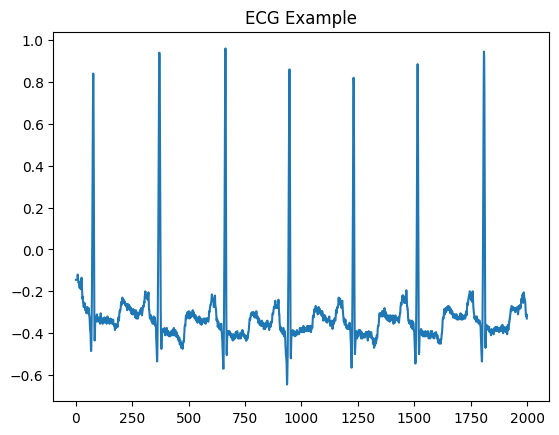

In [9]:
import wfdb
import matplotlib.pyplot as plt

record = wfdb.rdrecord('100', pn_dir='mitdb')
ann = wfdb.rdann('100', 'atr', pn_dir='mitdb')

signal = record.p_signal[:, 0]

plt.plot(signal[:2000])
plt.title("ECG Example")
plt.show()


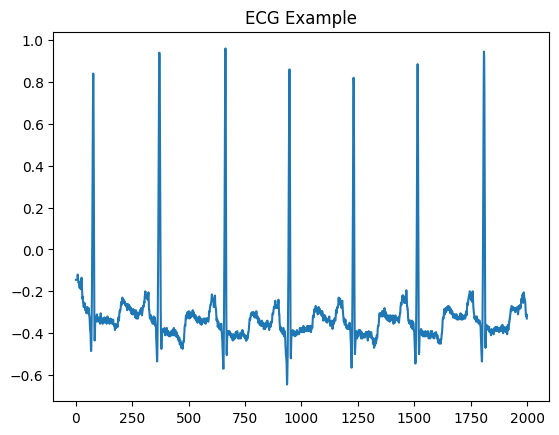

In [10]:
## Data Loading from data/mitbih
## with WFDB
from pathlib import Path
import matplotlib.pyplot as plt
import wfdb

data_root = _default_data_root()
## 100번 레코드 로드
record = wfdb.rdrecord(str(data_root / "100"))
## 100번 레코드의 atr 애널라이즈 로드
ann = wfdb.rdann(str(data_root / "100"), "atr")

signal = record.p_signal[:, 0]

plt.plot(signal[:2000])
plt.title("ECG Example")
plt.show()


### Parameter Notes
- `record_id`: "100", "101" 등 원하는 레코드 ID.
- `channel_names`: `["MLII", "V5"]`처럼 특정 리드만 선택하거나 `None`으로 전체 로드.
- `sampfrom` / `sampto`: 긴 레코드를 부분만 빠르게 확인할 때 시작/끝 샘플 지정.
- `SegmentationConfig.pre_window` / `post_window`: R-peak 기준으로 자를 전·후 시간(기본 0.2s / 0.4s).
- `fs`: 로더와 세그멘트 모두 360 Hz를 사용하므로 `초 = 샘플 / 360`으로 모든 시간 지표를 계산.


### rdrecord / rdann 파라미터
- `record_name`: "100" 같은 파일명 또는 절대경로.
- `sampfrom` / `sampto`: 특정 구간만 읽어 속도를 높일 때 사용하는 샘플 인덱스.
- `physical`: `True`면 `p_signal`(mV), `False`면 `d_signal`(ADC) 반환.
- `channel_names`: `None`으로 전체 리드, 리스트로 선택 리드만 지정.
- `pn_dir`: PhysioNet에서 직접 스트리밍할 때만 사용.

**rdann 옵션**
- `extension`: 기본 `"atr"`(beat annotation). 필요하면 `"qrs"`, `"st"` 등으로 변경.
- `sampfrom` / `sampto`: annotation도 동일하게 구간 제한.
- `pn_dir`: 원격 접근 시만 설정.
- `return_label_elements=True`: 심볼 이외의 세부 라벨까지 받고 싶을 때 사용.


### 레코드 vs. 어노테이션 로드
- **Record load (`wfdb.rdrecord`)**
  - `.dat/.hea`에서 파형을 읽어 `(samples, channels)` 배열과 채널·샘플링 메타데이터를 반환.
- **Annotation load (`wfdb.rdann`)**
  - `.atr` 등에서 beat 이벤트를 가져와 `sample`(R-peak 위치)와 `symbol`(AAMI 라벨)을 획득.
- **정리**: 동일한 `record_id`로 두 함수를 호출해 신호와 라벨을 정확히 정렬한다.


Filtered Signal Plot (5–15 Hz Bandpass)

- QRS 에너지가 가장 또렷한 5–15 Hz 구간만 통과시켜 baseline wander(<5 Hz)와 muscle noise(>20 Hz)를 억제.
- 필터링된 파형을 보면 R-peak 성분이 강조돼 세그먼트 기준점 검증과 이상치 탐지의 기본 품질을 확보할 수 있음.
- Butterworth 4차 bandpass + filtfilt(영위상)로 적용 후 raw vs filtered를 비교해 필터 효과를 확인.


### Beat-level 세그먼트가 필요한 이유
- **모델 입력 표준화**: `segment_beats()`가 만든 `(num_beats, window_samples)`와 동일한 위치의 라벨을 매칭해야 CNN/AE가 beat 단위 학습을 수행할 수 있다.
- **라벨 정합성**: 창 경계 때문에 제외된 beat는 `keep_idx`로 필터링해 샘플-라벨 미스매치를 방지한다.
- **후처리 연계**: reconstruction error, hand-crafted feature 등을 계산할 때도 beat별 라벨이 있어야 임상적 threshold/시각화가 가능하다.


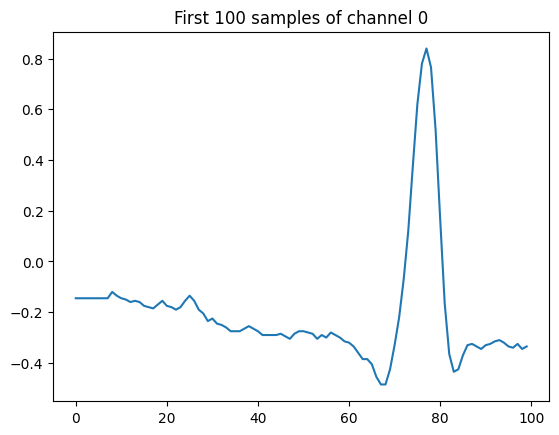

In [11]:
import pandas as pd
## 데이터를 알아보기
record =  wfdb.rdrecord(str(data_root / "100"))
## 데이터 프레임 형태로 변환
df = pd.DataFrame(record.p_signal, columns=record.sig_name)
## 첫 번째 채널의 처음 100개 샘플 표시
df.iloc[:100, 0].plot()
plt.title("First 100 samples of channel 0")
plt.show()

### 채널 메타데이터를 활용한 해석
- **MLII 예시**: 360 Hz, baseline 1024, gain 200 → `(raw-1024)/200`으로 mV 복원 가능.

**시간 기반 지표 (fs 활용)**
- RR 간격, 심박수, PR/QT/QTc, QRS 폭, PVC/APB 커플링 간격, ST 지연, T-wave alternans 등을 `샘플 / 360`으로 계산.
- 예) R-peak 차이가 180 샘플이면 0.5초 → 120 bpm.

**전압/형태 지표 (gain, baseline, units)**
- ST 상승/하강, R/Q/T 파 진폭, QRS 전압 규칙(Sokolow-Lyon, Cornell), P파 높이, T파 역전, PVC/Q-wave 깊이 등.
- baseline/gain을 적용해 mV로 환산 후 임상 기준(예: ST elevation ≥0.1 mV)과 비교.

**리드 해석 (channel)**
- MLII: 하벽, V5: 측벽/좌심실. 리드별 morphology 비교로 PVC 기원, 축 편위, 각차단 여부 판단.
- 리드별 노이즈나 flat-line을 확인해 전극 문제도 조기 탐지.

**신호 품질/처리 기준 (adc_res)**
- 11-bit(≈2048 단계) → 양자화 잡음/포화 여부 파악, Nyquist 180 Hz에 맞춘 필터 설계.

**진단 흐름 예시**
- RR 시퀀스로 HRV 또는 PVC 패턴 분석.
- 세그먼트 QRS 폭 >120 ms → wide QRS/VT 의심.
- R-peak+80 ms 전압 ≥0.2 mV → STEMI 후보.
- MLII vs V5 R/S 비율 차이 → 병변 위치 추정.
- `adc_res` 기준으로 포화 구간 제거, 0.5–40 Hz 필터 설계.


### 진단 적용 예시
- **PVC(조기 심실수축)**
  - RR 간격에서 앞/뒤 길이가 다르면 조기-보상 패턴.
  - QRS 폭 = `(QRS_end - QRS_start)/360` > 0.12 s이면 wide QRS.
  - `(raw-1024)/200`으로 환산한 진폭·형태가 정상 beat와 다르면 PVC 의심.
  - 리드별 morphology 비교로 기원을 추정.
- **ST Elevation MI**
  - R-peak + 80 ms(≈샘플 29) 전압이 ≥0.1 mV면 STEMI 후보.
  - MLII(하벽)와 V5(측벽)에서 동시에 상승하면 병변 위치 파악.
  - 상승 지속 시간과 동반 T파 변화를 함께 확인해 근거를 보강.


### 파라미터로 파생 가능한 분석 경우의 수
- 부정맥: RR 패턴 기반 PVC/APB/서맥/빈맥/AF 분류.
- 전도장애: PR 연장, QRS 폭 증가, QT 연장 측정.
- 허혈/심근경색: ST 상승·하강, T파 역전, 병변 위치 추론.
- 심실·심방 비대: R/S 전압 규칙과 P파 높이로 Sokolow-Lyon, Cornell 기준 계산.
- 전극/노이즈: 특정 리드의 baseline shift나 flat-line 탐지.
- HRV: RR 시계열로 LF/HF, RMSSD 등 자율신경 지표 계산.
- 정밀 morphology: T-wave alternans, 미세 artifact를 고해상도 전압으로 확인.


In [12]:
import pandas as pd
## 데이터를 알아보기
record =  wfdb.rdrecord(str(data_root / "100"))
param_table = pd.DataFrame({
    "channel": record.sig_name,
    "fs": record.fs,
    "gain": record.adc_gain,
    "baseline": record.baseline,
    "units": record.units,
    "adc_res": record.adc_res,
})
display(param_table)
print(f"Length (samples): {record.sig_len}, Duration (s): {record.sig_len / record.fs:.1f}")

,channel,fs,gain,baseline,units,adc_res
0,MLII,360,200.0,1024,mV,11
1,V5,360,200.0,1024,mV,11


Length (samples): 650000, Duration (s): 1805.6


### 파라미터 테이블 해석
- `channel`: MLII, V5 등 리드 이름 → 관찰 부위·노이즈 특성 파악.
- `fs`: 360 Hz 샘플링 → 시간 기반 지표 계산.
- `gain`: 200 µV/LSB → `(raw - baseline) / gain`으로 mV 환산.
- `baseline`: 1024 → ADC 오프셋, 실제 전압 복원 시 보정.
- `units`: mV → 임상 기준과 직접 비교 가능.
- `adc_res`: 11-bit → 디지털 해상도, 포화·양자화 잡음 판단.


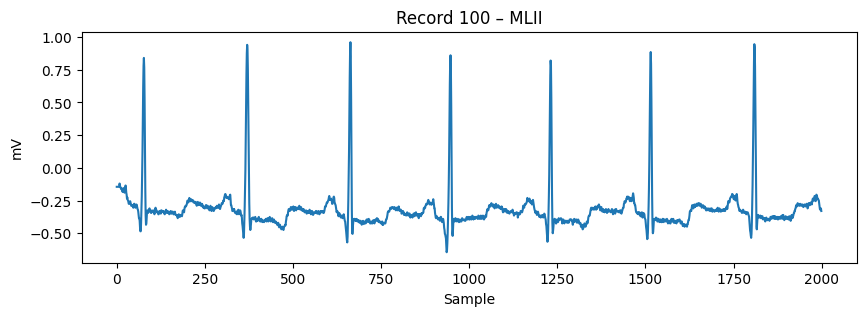

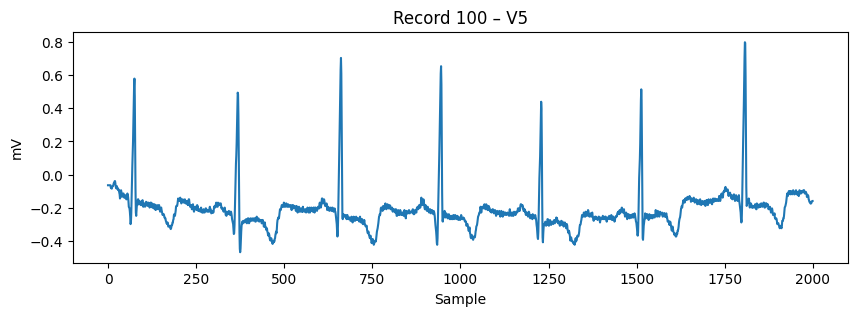

In [13]:
import matplotlib.pyplot as plt

for ch_idx, ch_name in enumerate(record.sig_name):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(record.p_signal[:2000, ch_idx])
    ax.set_title(f"Record 100 – {ch_name}")
    ax.set_xlabel("Sample")
    ax.set_ylabel("mV")
    plt.show()


In [14]:
from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
from scipy.signal import butter, filtfilt, find_peaks


def _bandpass(sig: np.ndarray, fs: float, lo: float = 5.0, hi: float = 15.0) -> np.ndarray:
    nyq = 0.5 * fs
    b, a = butter(4, [lo / nyq, hi / nyq], btype="band")
    return filtfilt(b, a, sig)

@dataclass
class SegmentationConfig:
    fs: float = 360.0
    pre_window: float = 0.2   # seconds before R-peak
    post_window: float = 0.4  # seconds after R-peak


def detect_r_peaks(
    signal: np.ndarray,
    fs: float = 360.0,
    *,
    distance_sec: float = 0.2,
    prominence: float | None = 0.3,
    bandpass: bool = True,
) -> np.ndarray:
    """Lightweight R-peak detector with refractory distance and optional bandpass."""
    sig = signal if signal.ndim == 1 else signal[:, 0]
    if bandpass:
        sig = _bandpass(sig, fs)
    distance = int(distance_sec * fs)
    peaks, _ = find_peaks(sig, distance=distance, prominence=prominence)
    return peaks


def segment_beats(
    signal: np.ndarray,
    r_peaks: np.ndarray,
    config: SegmentationConfig | None = None,
    *,
    channel: int | None = 0,
):
    config = config or SegmentationConfig()
    pre = int(config.pre_window * config.fs)
    post = int(config.post_window * config.fs)
    window = pre + post

    sig = signal
    if sig.ndim == 1:
        sig = sig[:, None]  # (N,) -> (N, 1)

    if channel is not None:
        sig = sig[:, [channel]]  # keep chosen channel to maintain (beats, window) output

    beats = []
    keep_idx = []
    for idx, peak in enumerate(r_peaks):
        start = peak - pre
        stop = peak + post
        if start < 0 or stop > sig.shape[0]:
            continue
        window_slice = sig[start:stop]
        # Flatten if single-channel to match prior shape expectations
        beats.append(window_slice[:, 0] if window_slice.shape[1] == 1 else window_slice)
        keep_idx.append(idx)

    if beats:
        segments = np.stack(beats, axis=0)
    else:
        empty_shape = (0, window) if sig.shape[1] == 1 else (0, window, sig.shape[1])
        segments = np.empty(empty_shape)

    meta = {
        "r_peaks": np.asarray(r_peaks[keep_idx], dtype=np.int32),
        "window": np.asarray([pre, post], dtype=np.int32),
        "channels": sig.shape[1],
    }
    return segments, meta


In [15]:
config = SegmentationConfig(pre_window=0.2, post_window=0.4)
peaks = detect_r_peaks(signal)
segments, seg_meta = segment_beats(signal, peaks, config)

In [16]:

# signal, meta는 load_record(...)로 불러온 결과라고 가정
config = SegmentationConfig(pre_window=0.2, post_window=0.4)  # 기본값
segments, seg_meta = segment_beats(signal, peaks, config)

print(segments.shape)         # (num_beats, window_samples)
print(seg_meta["r_peaks"][:5])


(2278, 216)
[  77  370  663  947 1231]


In [17]:
def _require_wfdb() -> None:
    if wfdb is None:
        raise ImportError(
            "wfdb is required to read MIT-BIH records. Install it via pip install wfdb"
        )

def load_record(
    record_id: str,
    *,
    data_root: Path | None = None,
    channels: Optional[Iterable[str]] = None,
    physical: bool = True,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """Load a full-length record along with annotations."""
    _require_wfdb()
    data_root = data_root or _default_data_root()
    record_path = str(data_root / record_id)
    record = wfdb.rdrecord(record_path, channel_names=channels, physical=physical)
    annotation = wfdb.rdann(record_path, "atr")
    signal = record.p_signal if physical else record.d_signal
    meta: Dict[str, np.ndarray] = {
        "sample": np.asarray(annotation.sample, dtype=np.int32),
        "symbol": np.asarray(annotation.symbol),
        "aux_note": np.asarray(annotation.aux_note),
    }
    return np.asarray(signal, dtype=np.float32), meta


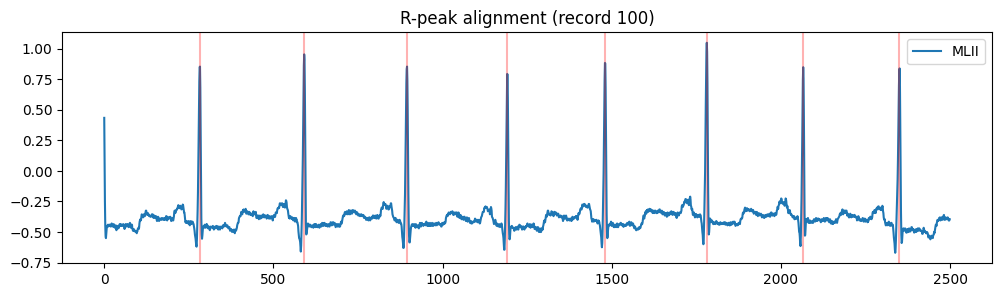

Symbol: N


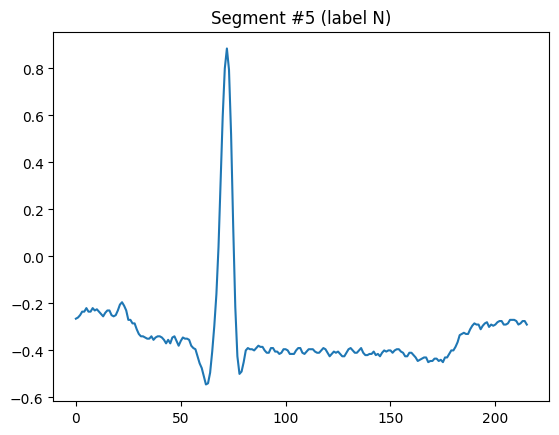

In [18]:

import numpy as np

signal, meta = load_record('100')                           # includes meta["sample"], meta["symbol"]
segments, seg_meta = segment_beats(signal, meta["sample"])  # default 0.2s pre / 0.4s post

# Plot one window with R-peaks marked
window = slice(10000, 12500)
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(signal[window, 0], label="MLII")
for peak in meta["sample"]:
    if window.start <= peak <= window.stop:
        ax.axvline(peak - window.start, color="red", alpha=0.3)
ax.legend()
ax.set_title("R-peak alignment (record 100)")
plt.show()

# Inspect a segmented beat and its label
idx = 5
print("Symbol:", meta["symbol"][idx])
plt.plot(segments[idx])
plt.title(f"Segment #{idx} (label {meta['symbol'][idx]})")
plt.show()


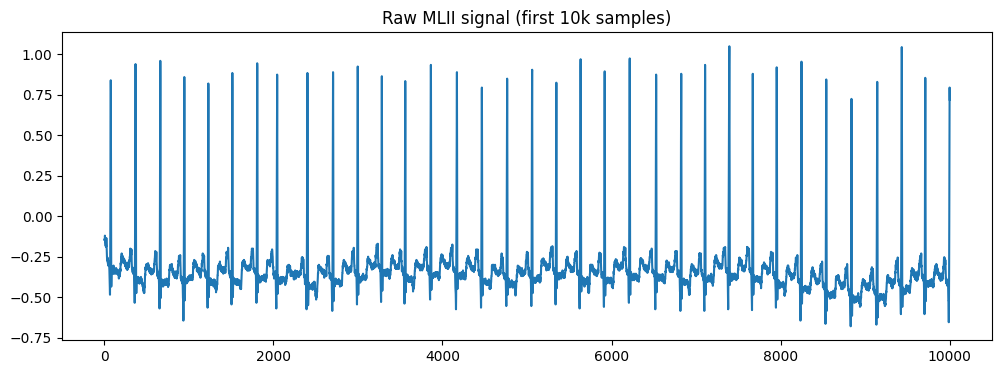

In [19]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

data_root = _default_data_root()
rec_path = data_root / "100"

record = wfdb.rdrecord(str(rec_path))
ann = wfdb.rdann(str(rec_path), "atr")

signal = record.p_signal[:, 0]   # MLII channel
fs = record.fs

plt.figure(figsize=(12,4))
plt.plot(signal[:10000])
plt.title("Raw MLII signal (first 10k samples)")
plt.show()


baseline drift 심한지

high-frequency noise 있는지

QRS peak 눈으로 구분 가능한지

(2) Filtered signal plot (5–15 Hz bandpass)

→ QRS가 또렷해지고 이상치 파형이 더 두드러짐.

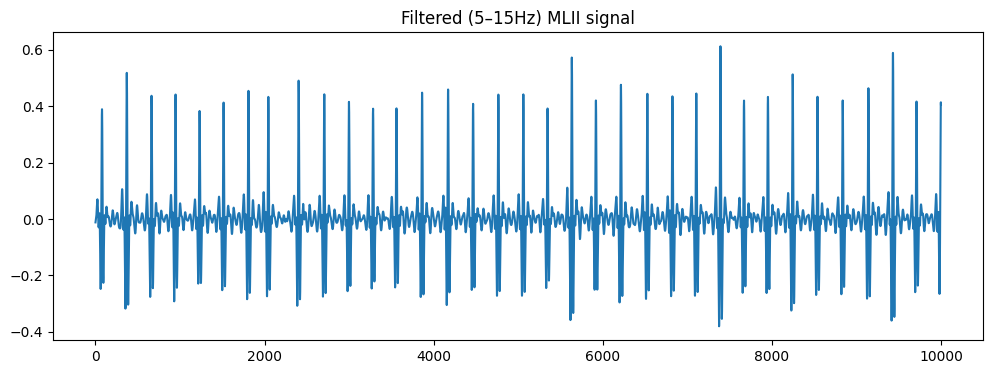

In [20]:
from scipy.signal import butter, filtfilt


def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a


def bandpass_filter(x, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order)
    return filtfilt(b, a, x)

# Use previously loaded record/signal; fall back to first channel
sig = signal if 'signal' in locals() else record.p_signal[:, 0]
fs = record.fs if 'record' in locals() else 360.0

filt = bandpass_filter(sig, 5, 15, fs, order=4)

window = slice(0, 5000)
plt.figure(figsize=(12,4))
plt.plot(sig[window], label='raw', alpha=0.4)
plt.plot(filt[window], label='filtered 5–15 Hz', linewidth=1.2)
plt.title('Raw vs Filtered (5–15 Hz) MLII')
plt.legend()
plt.show()


QRS complex가 선명하게 보이는지

baseline wander 제거됐는지

Noise 제거 수준이 적절한지

이건 anomaly detection의 preprocessing 품질을 결정함!

3) Annotation Overlay Plot (이상치 근처)

왜?

A, V beat가 실제로 어떻게 생겼는지 눈으로 확인해야
“정상 vs 이상” 기준이 생김.

해야 할 행동

A beats 3개

V beat 1개

그 주변 ±2초 신호 시각화

vertical line(annot) 추가

4) Segment Extraction 테스트 (정상/이상 3개씩)
이후 모델 입력이 될 “beat 단위 segment” 구조를 만들어놔야 하기 때문.

세그먼트 기준

pre: 200 ms = 72 sample
post: 400 ms = 144 sample
총 길이: 216 sample
해야 할 행동

N 3개
A 3개
V 1개

Shape 출력 + Plot

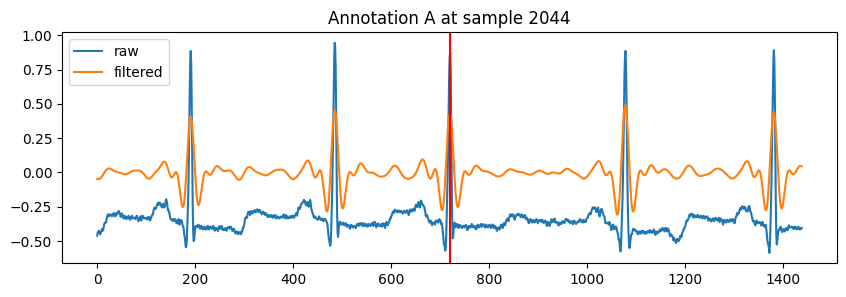

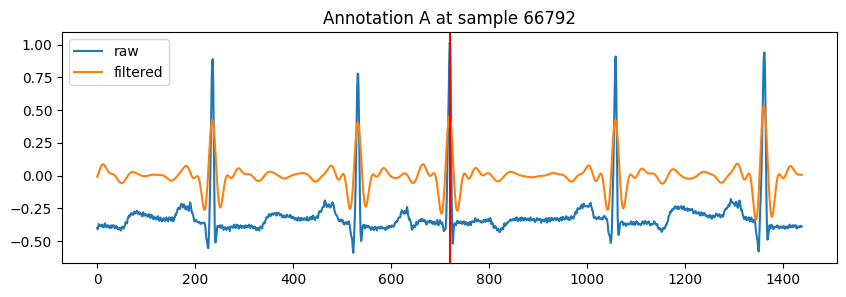

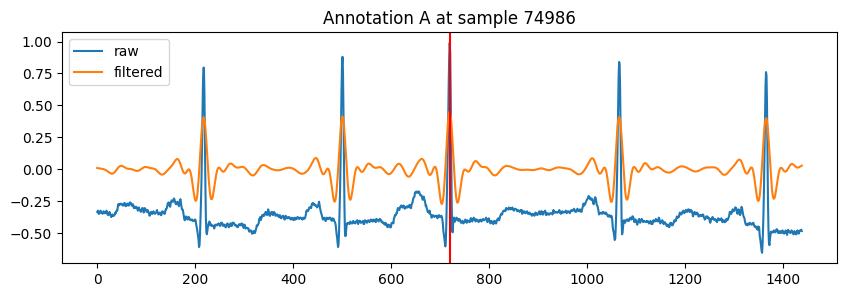

In [21]:
## beat 단위 세그먼트 추출
## Segment config

# pre: 200 ms = 72 sample
# post: 400 ms = 144 sample
# 총 길이: 216 sample

# anomaly indices
abn_idx = [i for i, s in enumerate(ann.symbol) if s in ['A','V','F']]
abn_idx[:5]  # 앞부분만 확인

for idx in abn_idx[:3]:
    pos = ann.sample[idx]
    start = max(0, pos - fs*2)
    end = min(len(signal), pos + fs*2)

    plt.figure(figsize=(10,3))
    plt.plot(signal[int(start):int(end)], label='raw')
    plt.plot(filt[int(start):int(end)], label='filtered')
    plt.axvline(x=pos-start, color='r')
    plt.title(f"Annotation {ann.symbol[idx]} at sample {pos}")
    plt.legend()
    plt.show()



A beat (atrial premature)의 형태

(A) N vs A vs V 구조적 차이
N (정상)
일정한 RR interval
QRS amplitude 일정
Morphology 변화 거의 없음

A (Atrial premature beat)
RR interval이 갑자기 짧아짐 (early beat)
P-wave 변화 / QRS 흔들림
형태가 정상과 비슷하지만 timing이 다름

V (Ventricular premature beat)
QRS 폭이 훨씬 크고 넓음 (sharp peak)
amplitude 튀어나옴
morphology가 아예 다름

→ 즉 A는 “timing-based anomaly”, V는 “shape-based anomaly”

amplitude vs shape 기반 anomaly 구분

A: amplitude nearly same → 하지만 “위치/간격의 이상”
V: amplitude + shape 모두 이상

즉 anomaly detection 방식도 달라짐:

A-type: sequence anomaly / timing anomaly
V-type: morphology anomaly / shape anomaly

너가 anomaly detection 모델을 만들 때
왜 Autoencoder만으로는 A를 못 잡는지?

V beat (PVC)의 형태
Normal과 무엇이 다른지 눈으로 확인 가능
세그먼트 기준(전후 몇 ms?) 잡기 쉬워짐"

모델 입력 형태 확인 (216 samples)

neural network 입력 shape: (batch, 216)

raw vs filtered 비교 → filtered만 쓰는 게 더 robust

segment stacking 형태도 체크

In [159]:
pre = int(0.2 * fs)   # 200ms
post = int(0.4 * fs)  # 400ms

segments = []
labels = []

for s, sym in zip(ann.sample, ann.symbol):
    if s-pre < 0 or s+post > len(signal):
        continue
    seg = signal[s-pre : s+post]
    segments.append(seg)
    labels.append(sym)

segments = np.array(segments)


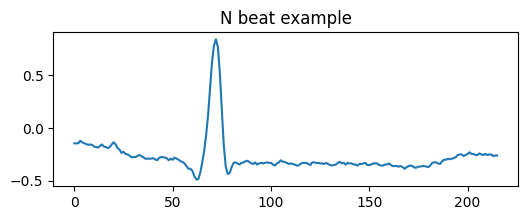

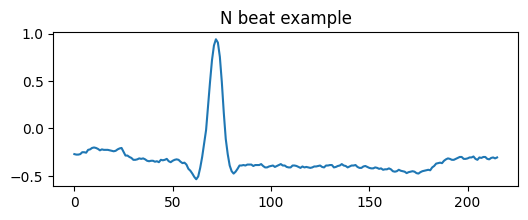

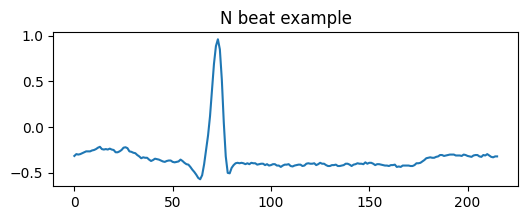

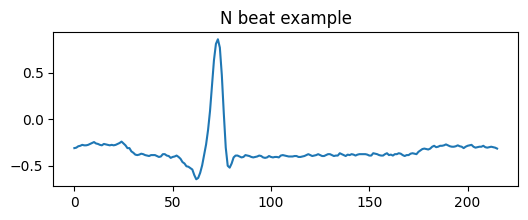

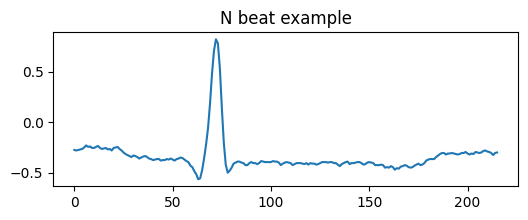

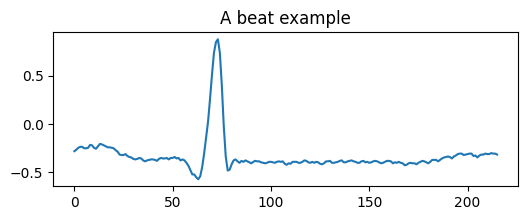

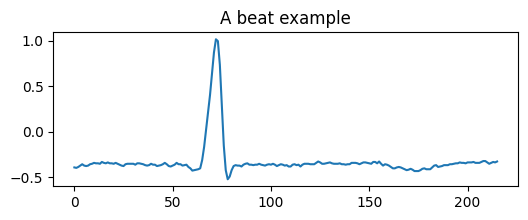

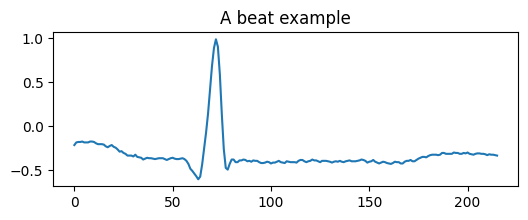

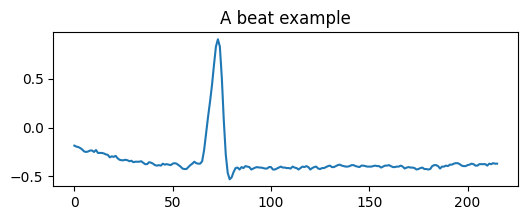

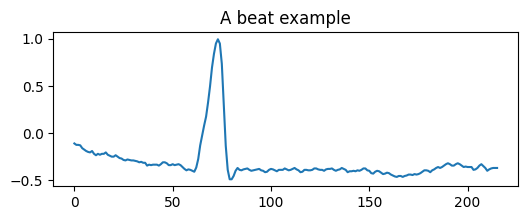

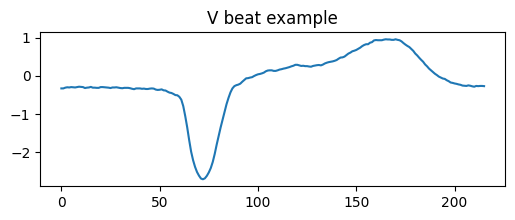

In [160]:
def plot_examples(target, n=5):
    idx = [i for i,l in enumerate(labels) if l == target]

    for i in idx[:n]:
        plt.figure(figsize=(6,2))
        plt.plot(segments[i])
        plt.title(f"{target} beat example")
        plt.show()

plot_examples('N', 5)
plot_examples('A', 5)
plot_examples('V', 1)


이 단계로 알 수 있는 것
N vs A vs V의 “구조적 차이”
anomaly가 amplitude 기반인지, shape 기반인지
필터링된 beat 기준 모델 입력 형태 확인
다음 단계인 특징 추출 / Autoencoder / 1D-CNN 설계에 기초가 되는 인사이트 확보